# CSE457 – XỬ LÝ ÂM THANH VÀ TIẾNG NÓI
# LAB 1 – PHÂN TÍCH VÀ XỬ LÝ TÍN HIỆU ÂM THANH SỐ

Notebook hoàn chỉnh cho các Task A → G.

**File đầu vào cần có trong thư mục `audio/`:**
- `file_example_WAV_10MG.wav` – file nhạc chính, dùng cho phần lớn thí nghiệm.
- `harvard.wav` – file tiếng nói, dùng cho phần thí nghiệm độc lập.

Notebook tạo các hình trong `figures/` và các file âm thanh xử lý trong `audio/`.


In [8]:
# Cài đặt thư viện (chạy 1 lần trên Google Colab)
!pip -q install pydub soundfile librosa

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from pydub import AudioSegment
from IPython.display import Audio, display

os.makedirs("audio", exist_ok=True)
os.makedirs("figures", exist_ok=True)

MAIN_FILE = "audio/file_example_WAV_10MG.wav"
SPEECH_FILE = "audio/harvard.wav"

print("Kiểm tra file:")
print(MAIN_FILE, "->", os.path.exists(MAIN_FILE))
print(SPEECH_FILE, "->", os.path.exists(SPEECH_FILE))


Kiểm tra file:
audio/file_example_WAV_10MG.wav -> True
audio/harvard.wav -> True


## Hàm dùng chung

In [9]:
def load_audio_mono(path):
    audio = AudioSegment.from_file(path)
    raw = np.array(audio.get_array_of_samples(), dtype=np.float64)

    if audio.channels > 1:
        raw = raw.reshape((-1, audio.channels))
        mono = raw.mean(axis=1)
    else:
        mono = raw

    max_value = float(2 ** (8 * audio.sample_width - 1))
    x = mono / max_value
    x = np.clip(x, -1, 1)

    return audio, x, audio.frame_rate


def rms(x):
    return np.sqrt(np.mean(x ** 2))


def peak(x):
    return np.max(np.abs(x))


def energy(x):
    return np.sum(x ** 2)


def clipping_count(x):
    return np.sum(np.abs(x) >= 1.0)


def save_wav(path, x, fs):
    x16 = np.int16(np.clip(x, -1, 1) * 32767)
    from scipy.io import wavfile
    wavfile.write(path, fs, x16)


def spectrum(x, fs, nfft=4096, window=None):
    if window is not None:
        x = x * window
    X = np.fft.rfft(x, n=nfft)
    f = np.fft.rfftfreq(nfft, 1 / fs)
    mag = np.abs(X)
    db = 20 * np.log10(np.maximum(mag, 1e-12))
    return f, mag, db


# TASK A – Đọc và kiểm tra dữ liệu âm thanh

Yêu cầu: kiểm tra Fs, số kênh, duration, dtype/sample width, file size; nếu stereo thì chuyển mono bằng trung bình hai kênh; chuẩn hóa về [-1, 1].


In [10]:
def metadata(path):
    audio = AudioSegment.from_file(path)
    raw = np.array(audio.get_array_of_samples())

    return {
        "File": os.path.basename(path),
        "Format": os.path.splitext(path)[1].upper(),
        "Sampling rate (Hz)": audio.frame_rate,
        "Channels": audio.channels,
        "Duration (s)": len(audio) / 1000,
        "Sample width (bytes)": audio.sample_width,
        "Bit depth": audio.sample_width * 8,
        "dtype": str(raw.dtype),
        "File size (bytes)": os.path.getsize(path)
    }

metadata_df = pd.DataFrame([
    metadata(MAIN_FILE),
    metadata(SPEECH_FILE)
])

display(metadata_df)
metadata_df.to_csv("audio_metadata_taskA.csv", index=False)


,File,Format,Sampling rate (Hz),Channels,Duration (s),Sample width (bytes),Bit depth,dtype,File size (bytes)
0,file_example_WAV_10MG.wav,.WAV,44100,2,59.773,2,16,int16,10544134
1,harvard.wav,.WAV,44100,2,18.356,2,16,int16,3249924


MAIN FILE
Fs = 44100 Hz
Channels = 2
Duration = 59.77297052154195 s
Mono samples = 2635988
Peak = 0.4367828369140625
RMS = 0.0960057581507568
Range = (np.float64(-0.394012451171875), np.float64(0.4367828369140625))

RMS Left = 0.1041762425319726
RMS Right = 0.096902796284931
RMS Mono = 0.0960057581507568


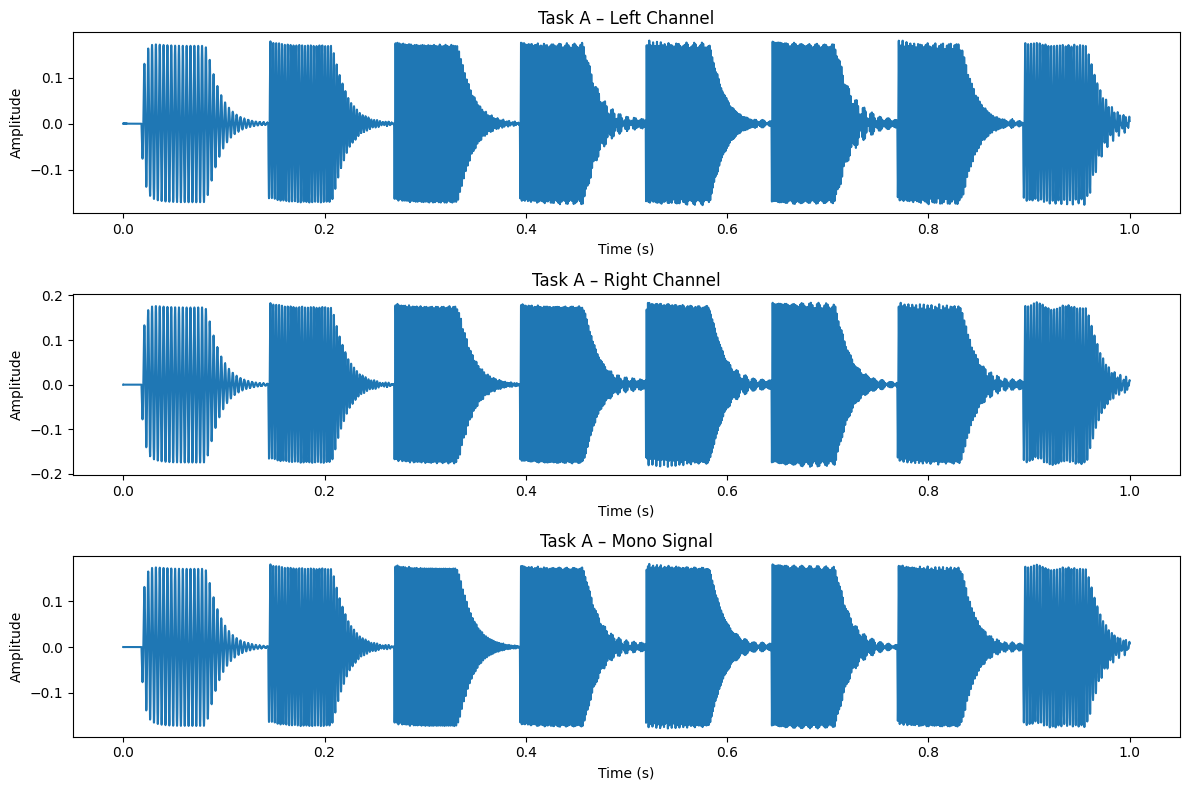

In [11]:
audio_main, x_main, Fs = load_audio_mono(MAIN_FILE)
audio_speech, x_speech, Fs_speech = load_audio_mono(SPEECH_FILE)

print("MAIN FILE")
print("Fs =", Fs, "Hz")
print("Channels =", audio_main.channels)
print("Duration =", len(x_main) / Fs, "s")
print("Mono samples =", len(x_main))
print("Peak =", peak(x_main))
print("RMS =", rms(x_main))
print("Range =", (x_main.min(), x_main.max()))

# So sánh Left / Right / Mono nếu file chính là stereo
raw = np.array(audio_main.get_array_of_samples(), dtype=np.float64)
if audio_main.channels == 2:
    stereo = raw.reshape((-1, 2))
    scale = 2 ** (8 * audio_main.sample_width - 1)
    left = stereo[:, 0] / scale
    right = stereo[:, 1] / scale
    mono = stereo.mean(axis=1) / scale

    print("\nRMS Left =", rms(left))
    print("RMS Right =", rms(right))
    print("RMS Mono =", rms(mono))

    N = min(Fs, len(mono))
    t = np.arange(N) / Fs

    plt.figure(figsize=(12, 8))
    plt.subplot(3, 1, 1)
    plt.plot(t, left[:N])
    plt.title("Task A – Left Channel")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    plt.subplot(3, 1, 2)
    plt.plot(t, right[:N])
    plt.title("Task A – Right Channel")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    plt.subplot(3, 1, 3)
    plt.plot(t, mono[:N])
    plt.title("Task A – Mono Signal")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    plt.tight_layout()
    plt.savefig("figures/taskA_stereo_mono.png", dpi=150)
    plt.show()

save_wav("audio/mono_norm.wav", x_main, Fs)


### Nhận xét Task A

- File chính có thể được đưa về mono bằng cách lấy trung bình hai kênh stereo.
- Chuẩn hóa giúp tín hiệu nằm trong miền xấp xỉ [-1, 1], thuận tiện cho các phép xử lý tiếp theo.
- Fs quyết định giới hạn Nyquist bằng Fs/2; với Fs = 44.1 kHz, giới hạn Nyquist là 22.05 kHz.
- Các phép tính RMS và peak sau khi chuẩn hóa có thể dùng trực tiếp để so sánh mức tín hiệu.


# TASK B – Phân tích miền thời gian

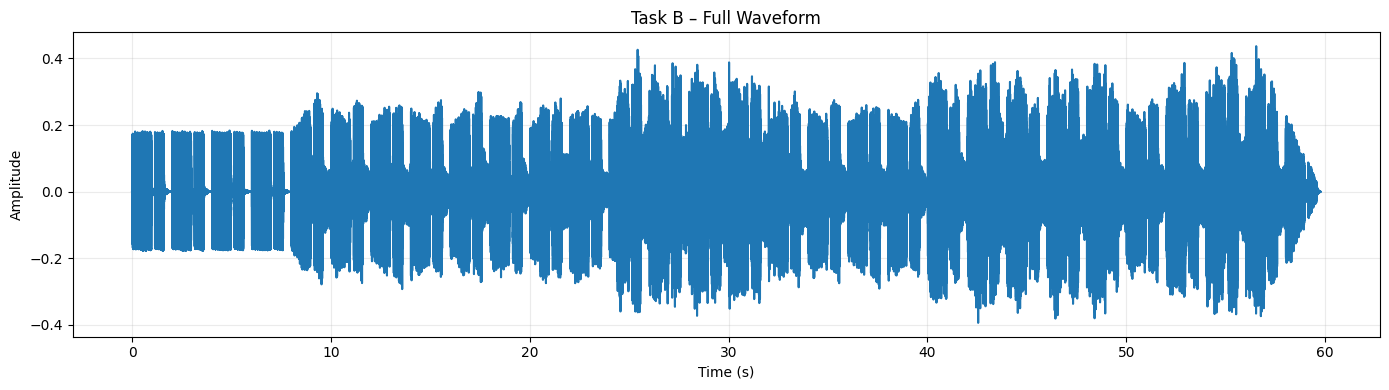

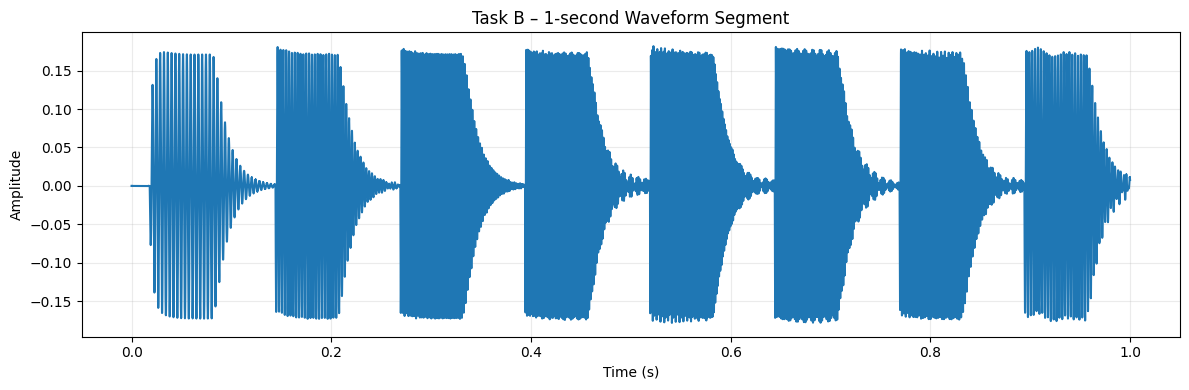

,Segment,Peak,RMS,Energy,Clipping count
0,Segment 1 – first 1s,0.181778,0.091337,367.901761,0
1,Segment 2 – highest RMS 1s,0.416397,0.130844,754.996826,0


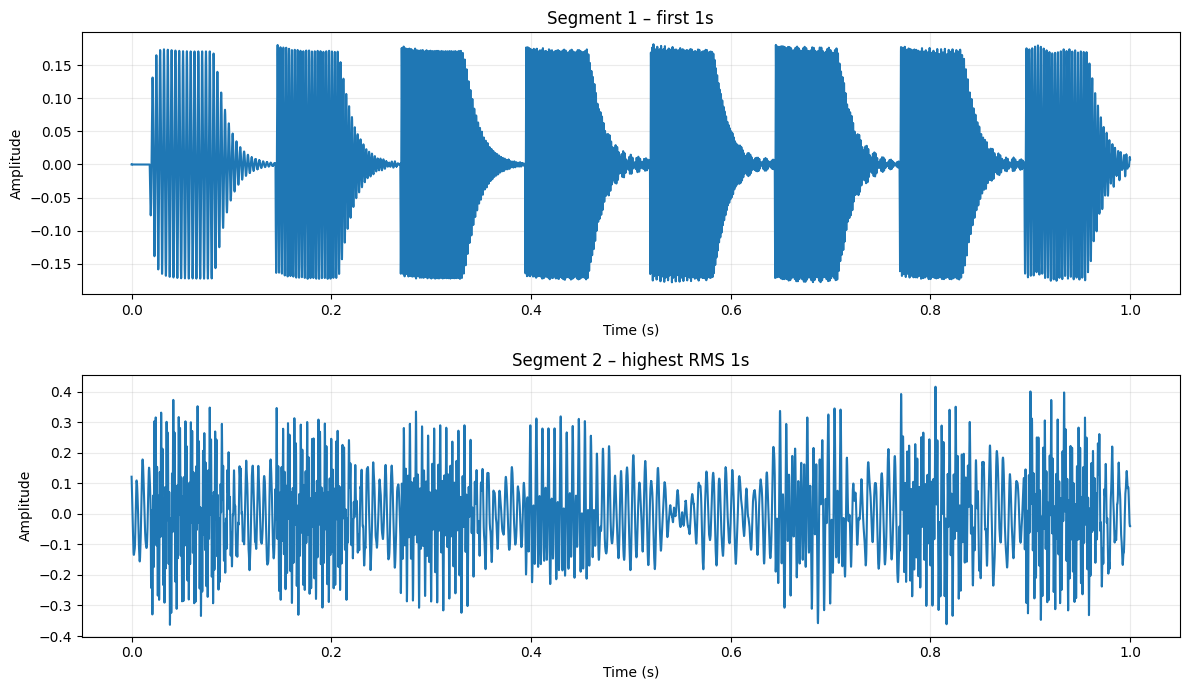

In [12]:
# Waveform toàn tệp
t_full = np.arange(len(x_main)) / Fs

plt.figure(figsize=(14, 4))
plt.plot(t_full, x_main)
plt.title("Task B – Full Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("figures/taskB_full_waveform.png", dpi=150)
plt.show()

# Đoạn 1 giây
seg_len = min(Fs, len(x_main))
seg0 = x_main[:seg_len]
t_seg = np.arange(len(seg0)) / Fs

plt.figure(figsize=(12, 4))
plt.plot(t_seg, seg0)
plt.title("Task B – 1-second Waveform Segment")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("figures/taskB_1s_waveform.png", dpi=150)
plt.show()

# Hai đoạn có đặc tính khác nhau: đoạn đầu và đoạn có RMS cao nhất
window = Fs
rms_values = []
starts = range(0, len(x_main) - window + 1, max(1, Fs // 10))

for s in starts:
    rms_values.append(rms(x_main[s:s+window]))

max_idx = int(np.argmax(rms_values))
start_high = list(starts)[max_idx]

segments_B = {
    "Segment 1 – first 1s": x_main[:window],
    "Segment 2 – highest RMS 1s": x_main[start_high:start_high+window]
}

rows = []
for name, x in segments_B.items():
    rows.append({
        "Segment": name,
        "Peak": peak(x),
        "RMS": rms(x),
        "Energy": energy(x),
        "Clipping count": clipping_count(x)
    })

taskB_df = pd.DataFrame(rows)
display(taskB_df)
taskB_df.to_csv("taskB_time_domain.csv", index=False)

plt.figure(figsize=(12, 7))
for i, (name, x) in enumerate(segments_B.items(), 1):
    plt.subplot(2, 1, i)
    tt = np.arange(len(x)) / Fs
    plt.plot(tt, x)
    plt.title(name)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("figures/taskB_two_segments.png", dpi=150)
plt.show()


### Nhận xét Task B

- Peak biểu diễn biên độ cực đại, RMS phản ánh mức năng lượng hiệu dụng của tín hiệu.
- Đoạn có RMS lớn hơn chứa mức năng lượng trung bình cao hơn.
- Energy tăng khi biên độ tín hiệu lớn hoặc đoạn tín hiệu dài hơn.
- Clipping được kiểm tra bằng các mẫu đạt hoặc vượt biên độ ±1 sau chuẩn hóa.
- Hai đoạn được chọn có RMS khác nhau để tạo một phép so sánh rõ ràng trong miền thời gian.


# TASK C – FFT và phân tích miền tần số

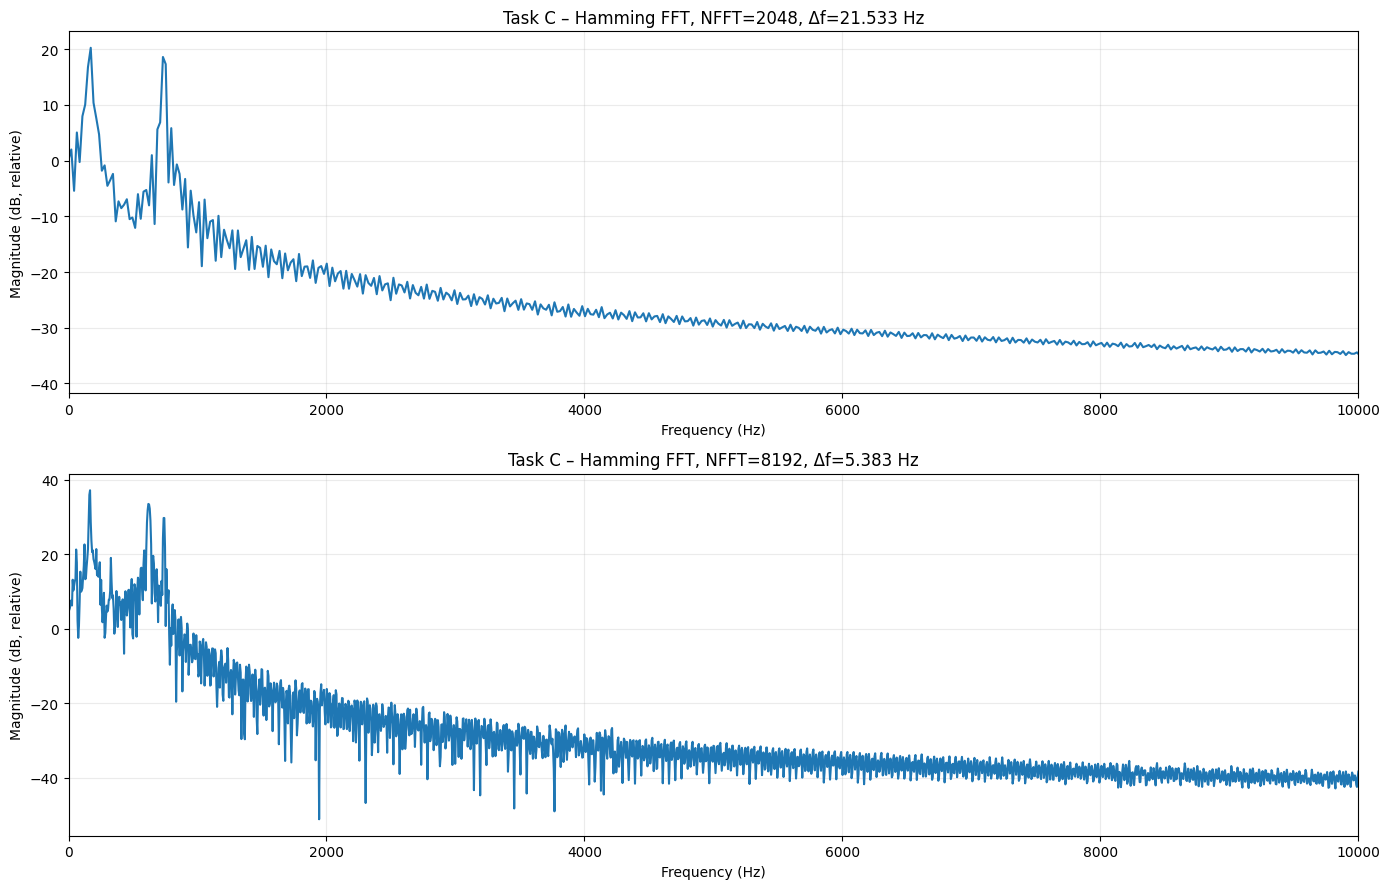

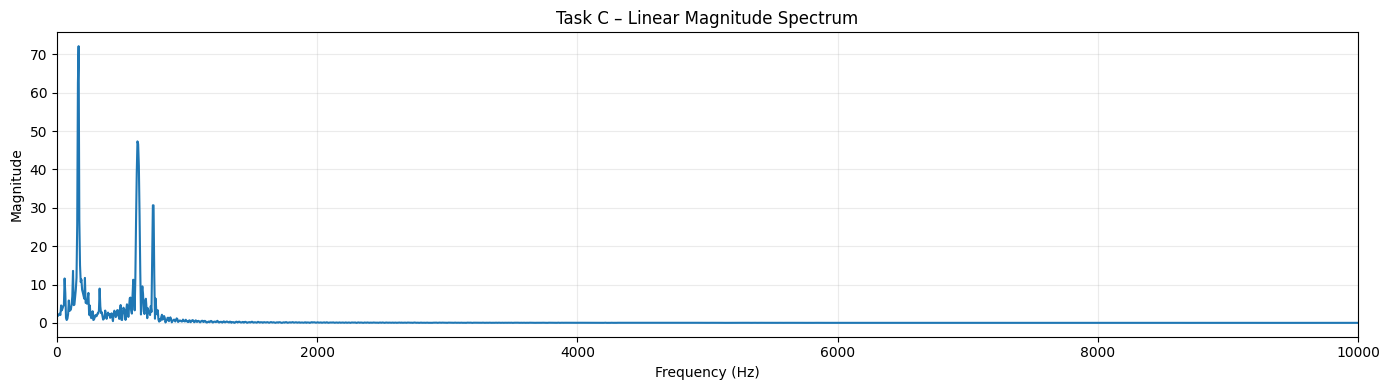

,Peak,Frequency (Hz),Magnitude,Magnitude (dB)
0,1,166.882324,72.156922,37.165560
1,2,619.079590,47.326288,33.502049
2,3,737.512207,30.674581,29.735573


Frequency-bin spacing:
NFFT=2048: Δf = 21.5332 Hz
NFFT=8192: Δf = 5.3833 Hz


In [13]:
# Chọn đoạn 1 giây có RMS cao nhất
seg_fft = x_main[start_high:start_high+Fs]
if len(seg_fft) < Fs:
    seg_fft = x_main[:Fs]

# Hamming
win = np.hamming(len(seg_fft))
NFFT_values = [2048, 8192]

fft_results = {}

plt.figure(figsize=(14, 9))

for i, nfft in enumerate(NFFT_values, 1):
    f, mag, db = spectrum(seg_fft, Fs, nfft=nfft, window=win)
    fft_results[nfft] = (f, mag, db)

    plt.subplot(2, 1, i)
    plt.plot(f, db)
    plt.xlim(0, min(10000, Fs/2))
    plt.title(f"Task C – Hamming FFT, NFFT={nfft}, Δf={Fs/nfft:.3f} Hz")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB, relative)")
    plt.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("figures/taskC_fft_comparison.png", dpi=150)
plt.show()

# Linear spectrum với NFFT=8192
f, mag, db = fft_results[8192]

plt.figure(figsize=(14, 4))
plt.plot(f, mag)
plt.xlim(0, min(10000, Fs/2))
plt.title("Task C – Linear Magnitude Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("figures/taskC_linear_spectrum.png", dpi=150)
plt.show()

# Tìm 3 peak nổi bật
from scipy.signal import find_peaks

peaks_idx, properties = find_peaks(mag, distance=20)
if len(peaks_idx) > 0:
    top = peaks_idx[np.argsort(mag[peaks_idx])[-3:]][::-1]
    peak_table = pd.DataFrame({
        "Peak": np.arange(1, len(top)+1),
        "Frequency (Hz)": f[top],
        "Magnitude": mag[top],
        "Magnitude (dB)": db[top]
    })
else:
    peak_table = pd.DataFrame()

display(peak_table)
peak_table.to_csv("taskC_spectral_peaks.csv", index=False)

print("Frequency-bin spacing:")
for nfft in NFFT_values:
    print(f"NFFT={nfft}: Δf = {Fs/nfft:.4f} Hz")


### Nhận xét Task C

- FFT chuyển đoạn tín hiệu từ miền thời gian sang miền tần số.
- Hamming được dùng để giảm spectral leakage trước khi FFT.
- Khi tăng NFFT từ 2048 lên 8192, khoảng cách giữa các frequency bin giảm từ Fs/2048 xuống Fs/8192.
- Tăng NFFT làm phổ được lấy mẫu dày hơn; không nên kết luận rằng true resolution tăng tương ứng vì độ phân giải thực còn phụ thuộc độ dài frame.
- Ba đỉnh lớn nhất được lấy trực tiếp từ phổ đo được của file âm thanh.


# TASK D – STFT và Spectrogram

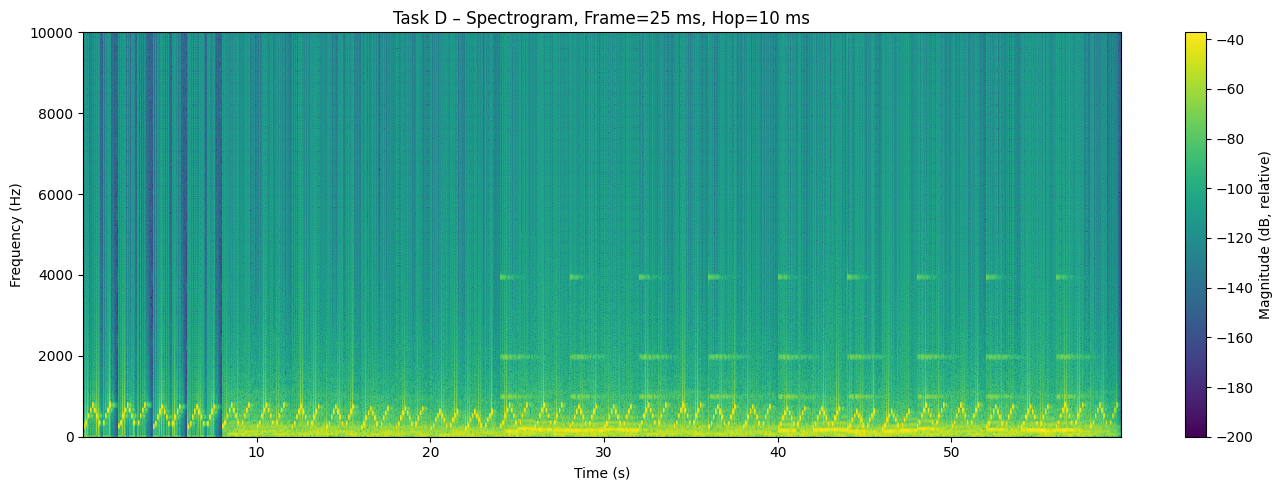

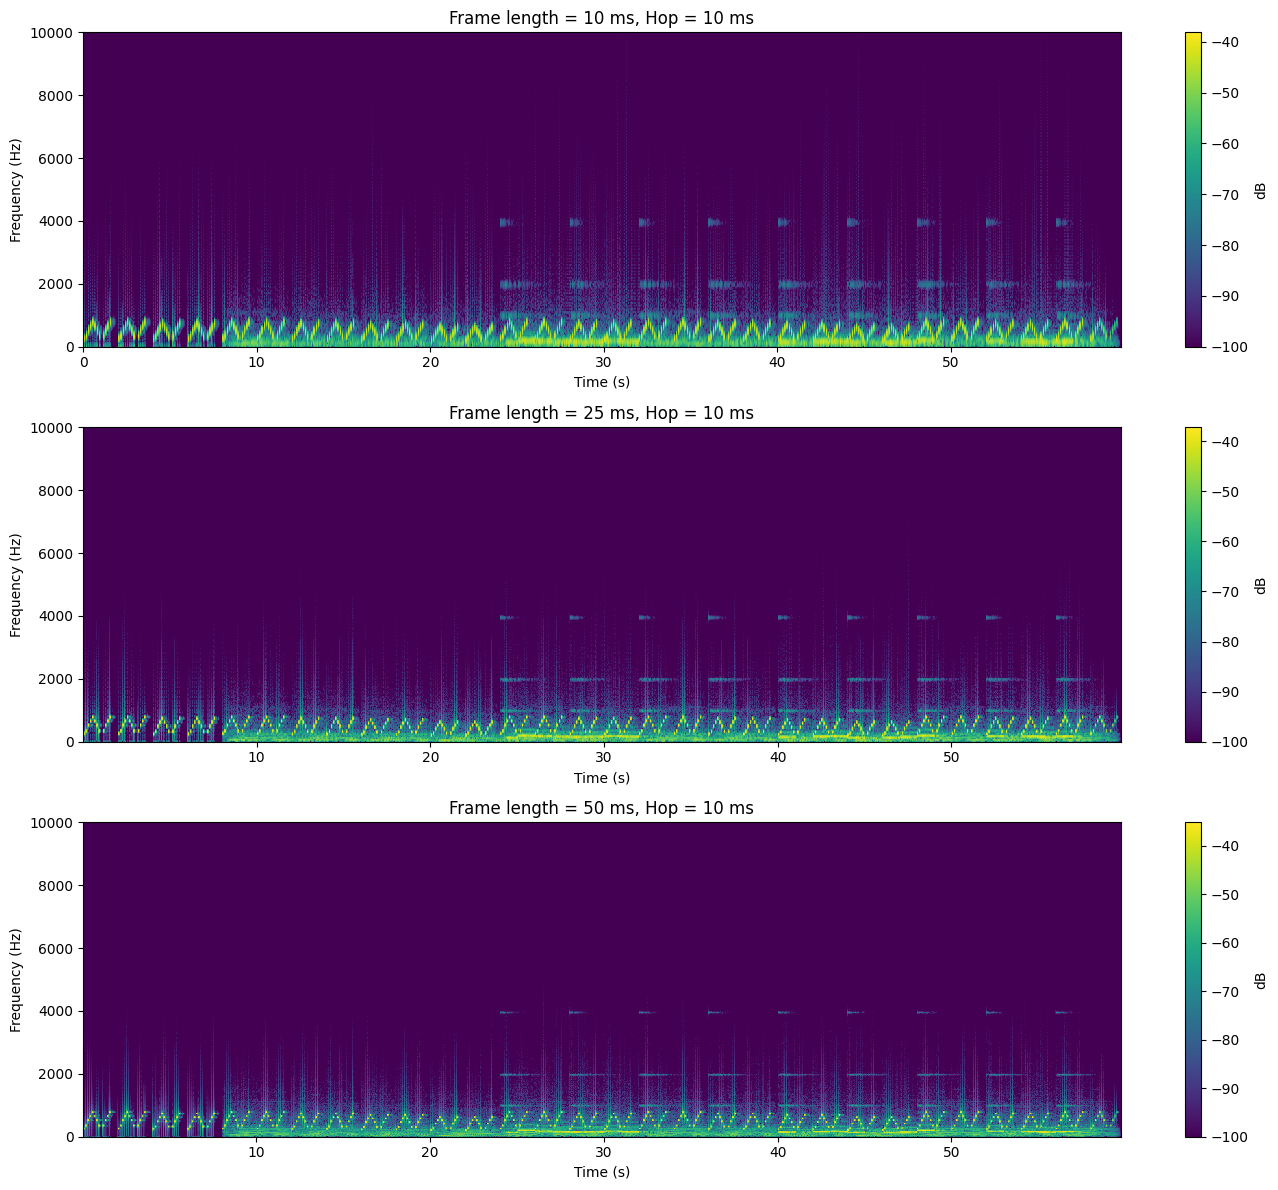

In [14]:
# D1: Spectrogram chuẩn 25 ms / 10 ms
L25 = round(0.025 * Fs)
H10 = round(0.010 * Fs)

f_stft, t_stft, S = signal.spectrogram(
    x_main,
    fs=Fs,
    window="hamming",
    nperseg=L25,
    noverlap=L25-H10,
    nfft=2048,
    mode="magnitude"
)

S_db = 20 * np.log10(np.maximum(S, 1e-10))

plt.figure(figsize=(14, 5))
plt.pcolormesh(t_stft, f_stft, S_db, shading="auto")
plt.ylim(0, min(10000, Fs/2))
plt.colorbar(label="Magnitude (dB, relative)")
plt.title("Task D – Spectrogram, Frame=25 ms, Hop=10 ms")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.tight_layout()
plt.savefig("figures/taskD_spectrogram_25ms.png", dpi=150)
plt.show()

# D2: So sánh 10 / 25 / 50 ms
frame_ms = [10, 25, 50]

plt.figure(figsize=(14, 12))

for i, ms in enumerate(frame_ms, 1):
    L = round(ms / 1000 * Fs)
    hop = round(0.010 * Fs)
    overlap = max(0, L - hop)

    f_tmp, t_tmp, S_tmp = signal.spectrogram(
        x_main,
        fs=Fs,
        window="hamming",
        nperseg=L,
        noverlap=overlap,
        nfft=max(2048, L),
        mode="magnitude"
    )

    S_tmp_db = 20 * np.log10(np.maximum(S_tmp, 1e-10))

    plt.subplot(3, 1, i)
    plt.pcolormesh(
        t_tmp,
        f_tmp,
        S_tmp_db,
        shading="auto",
        vmin=-100,
        vmax=np.max(S_tmp_db)
    )

    plt.ylim(0, min(10000, Fs/2))
    plt.colorbar(label="dB")
    plt.title(f"Frame length = {ms} ms, Hop = 10 ms")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")

plt.tight_layout()
plt.savefig("figures/taskD_frame_comparison.png", dpi=150)
plt.show()


### Nhận xét Task D

- Frame 10 ms có độ phân giải thời gian tốt hơn, phù hợp quan sát biến đổi nhanh nhưng độ phân giải tần số thấp hơn.
- Frame 25 ms là cấu hình cân bằng giữa thời gian và tần số và được dùng làm cấu hình chuẩn.
- Frame 50 ms cho cấu trúc tần số rõ hơn nhưng làm các biến đổi nhanh theo thời gian bị làm mờ.
- Trong các hình so sánh, thang màu được giữ cố định để việc so sánh có ý nghĩa.


# TASK E – So sánh Rectangular và Hamming Window

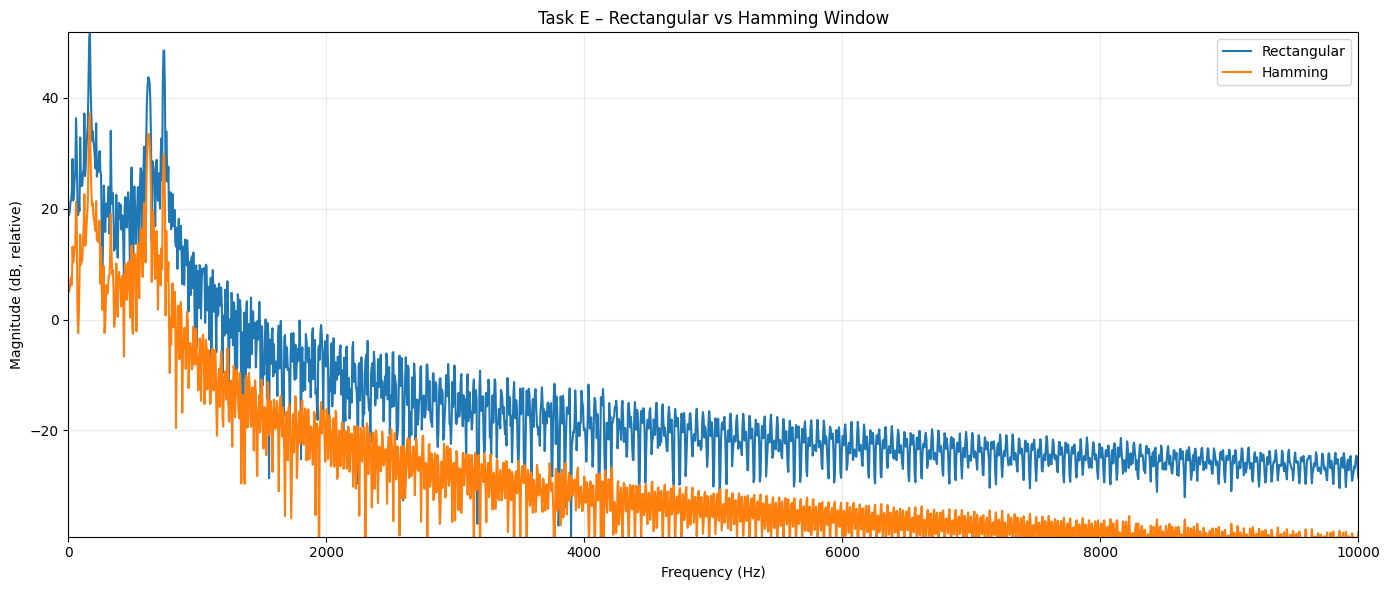

In [15]:
# Cùng một frame và cùng NFFT
frame_E = seg_fft[:min(len(seg_fft), Fs)]
NFFT_E = 8192

rect = np.ones(len(frame_E))
hamming = np.hamming(len(frame_E))

f_rect, mag_rect, db_rect = spectrum(frame_E, Fs, NFFT_E, rect)
f_ham, mag_ham, db_ham = spectrum(frame_E, Fs, NFFT_E, hamming)

plt.figure(figsize=(14, 6))
plt.plot(f_rect, db_rect, label="Rectangular")
plt.plot(f_ham, db_ham, label="Hamming")
plt.xlim(0, min(10000, Fs/2))
plt.ylim(max(np.min(db_rect), np.min(db_ham)), max(np.max(db_rect), np.max(db_ham)))
plt.title("Task E – Rectangular vs Hamming Window")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB, relative)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("figures/taskE_window_comparison.png", dpi=150)
plt.show()


### Nhận xét Task E

- Rectangular window có side-lobe lớn hơn nên spectral leakage thường rõ hơn.
- Hamming giảm side-lobe và leakage nhưng main-lobe rộng hơn.
- Vì dữ liệu, frame và NFFT được giữ nguyên nên khác biệt quan sát được chủ yếu đến từ loại cửa sổ.
- Main-lobe rộng có thể làm các đỉnh tần số gần nhau khó phân biệt hơn.


# TASK F – Lọc số FIR

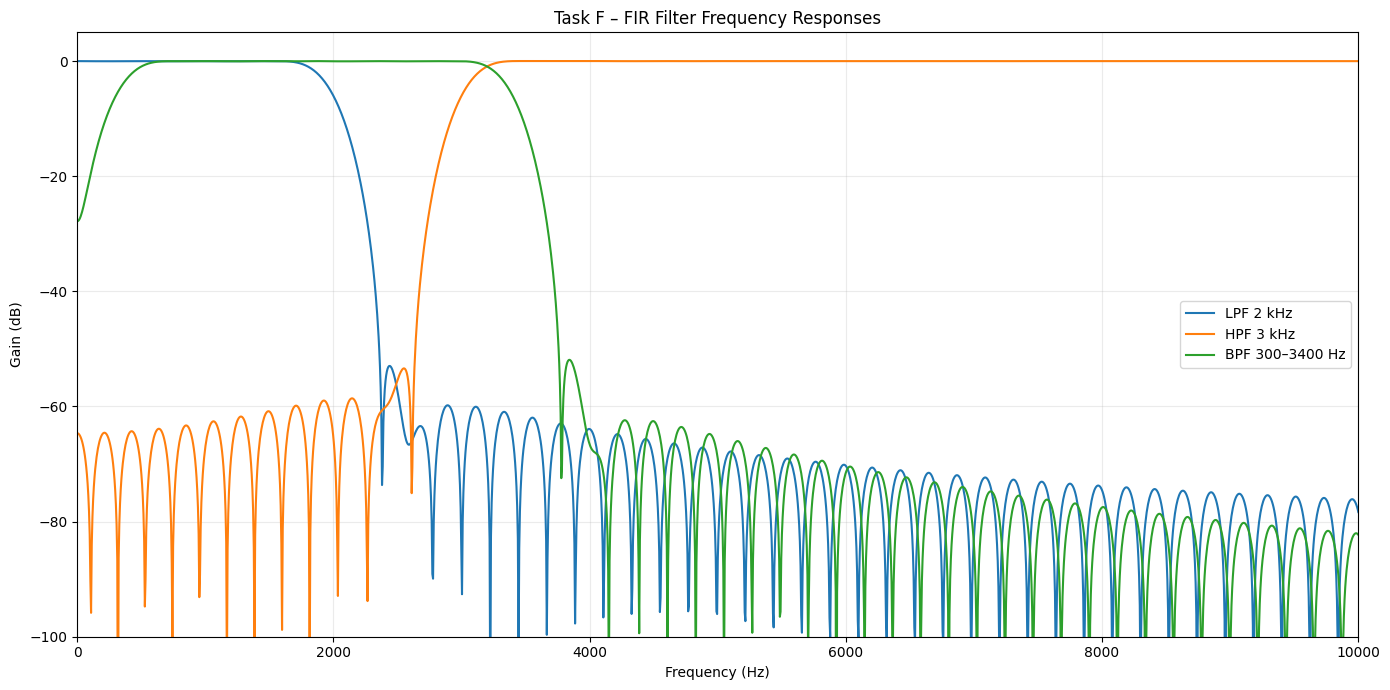

LPF first 10 coefficients:
[-5.56928888e-05  1.65011438e-05  8.97404129e-05  1.59235324e-04
  2.20091630e-04  2.67507779e-04  2.97028077e-04  3.04853661e-04
  2.88200031e-04  2.45675511e-04]
Group delay ≈ 100 samples = 2.268 ms


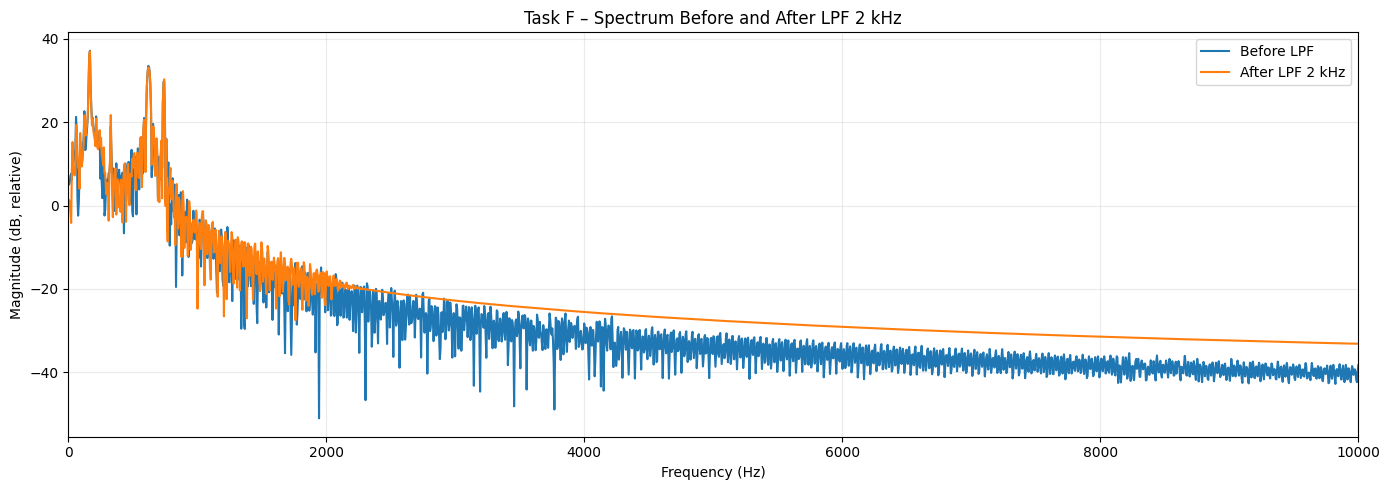

In [16]:
# Thiết kế FIR
numtaps = 201

b_lpf = signal.firwin(numtaps, cutoff=2000, fs=Fs, window="hamming")
b_hpf = signal.firwin(numtaps, cutoff=3000, fs=Fs, window="hamming", pass_zero=False)
b_bpf = signal.firwin(numtaps, cutoff=[300, 3400], fs=Fs, window="hamming", pass_zero=False)

# Frequency response
w_lpf, H_lpf = signal.freqz(b_lpf, worN=4096, fs=Fs)
w_hpf, H_hpf = signal.freqz(b_hpf, worN=4096, fs=Fs)
w_bpf, H_bpf = signal.freqz(b_bpf, worN=4096, fs=Fs)

plt.figure(figsize=(14, 7))
plt.plot(w_lpf, 20*np.log10(np.maximum(np.abs(H_lpf), 1e-10)), label="LPF 2 kHz")
plt.plot(w_hpf, 20*np.log10(np.maximum(np.abs(H_hpf), 1e-10)), label="HPF 3 kHz")
plt.plot(w_bpf, 20*np.log10(np.maximum(np.abs(H_bpf), 1e-10)), label="BPF 300–3400 Hz")
plt.xlim(0, min(10000, Fs/2))
plt.ylim(-100, 5)
plt.title("Task F – FIR Filter Frequency Responses")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Gain (dB)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("figures/taskF_filter_response.png", dpi=150)
plt.show()

# Áp dụng filter
y_lpf = signal.lfilter(b_lpf, [1.0], x_main)
y_hpf = signal.lfilter(b_hpf, [1.0], x_main)
y_bpf = signal.lfilter(b_bpf, [1.0], x_main)

save_wav("audio/filtered_lpf_2k.wav", y_lpf, Fs)
save_wav("audio/filtered_hpf_3k.wav", y_hpf, Fs)
save_wav("audio/filtered_bpf_300_3400.wav", y_bpf, Fs)

print("LPF first 10 coefficients:")
print(b_lpf[:10])

delay_samples = (numtaps - 1) / 2
delay_ms = delay_samples / Fs * 1000
print(f"Group delay ≈ {delay_samples:.0f} samples = {delay_ms:.3f} ms")

# So sánh phổ trước / sau LPF
analysis_seg = x_main[start_high:start_high+Fs]
if len(analysis_seg) < Fs:
    analysis_seg = x_main[:Fs]

filtered_seg = y_lpf[start_high:start_high+Fs]
if len(filtered_seg) < Fs:
    filtered_seg = y_lpf[:Fs]

f0, _, db0 = spectrum(analysis_seg, Fs, 8192, np.hamming(len(analysis_seg)))
f1, _, db1 = spectrum(filtered_seg, Fs, 8192, np.hamming(len(filtered_seg)))

plt.figure(figsize=(14, 5))
plt.plot(f0, db0, label="Before LPF")
plt.plot(f1, db1, label="After LPF 2 kHz")
plt.xlim(0, min(10000, Fs/2))
plt.title("Task F – Spectrum Before and After LPF 2 kHz")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB, relative)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("figures/taskF_before_after_lpf.png", dpi=150)
plt.show()


### Nhận xét Task F

- FIR LPF 2 kHz giữ thành phần tần số thấp và suy giảm thành phần cao hơn vùng cutoff.
- FIR HPF 3 kHz giữ thành phần cao và suy giảm thành phần thấp.
- BPF 300–3400 Hz giữ lại một dải tần trung tâm.
- Với FIR 201 taps đối xứng, group delay xấp xỉ (201−1)/2 = 100 mẫu.
- Ở Fs = 44.1 kHz, độ trễ lý thuyết xấp xỉ 2.27 ms.
- Phổ sau lọc thay đổi phù hợp với frequency response của bộ lọc.


# TASK G – Lượng tử hóa, Resampling và Coding

,Bit depth,Quantization levels,Measured SNR (dB)
0,4,16,8.205101
1,8,256,32.591687
2,16,65536,80.022627


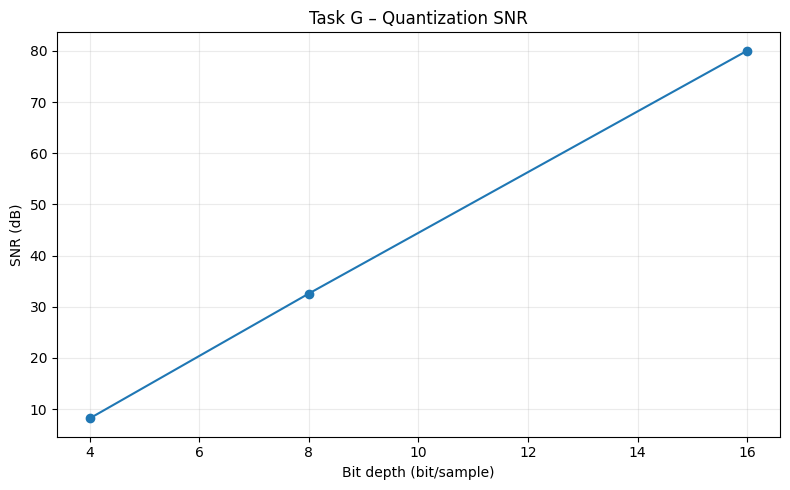

In [17]:
# G1. Quantization 4 / 8 / 16 bit

def quantize(x, B):
    qmax = 2**(B-1) - 1
    return np.round(np.clip(x, -1, 1) * qmax) / qmax


def snr_db(x, xq):
    error = xq - x
    signal_power = np.sum(x**2)
    noise_power = np.sum(error**2)

    if noise_power == 0:
        return np.inf

    return 10 * np.log10(signal_power / noise_power)


quant_results = []

for B in [4, 8, 16]:
    xq = quantize(x_main, B)
    snr = snr_db(x_main, xq)

    save_wav(f"audio/quantized_{B}bit.wav", xq, Fs)

    quant_results.append({
        "Bit depth": B,
        "Quantization levels": 2**B,
        "Measured SNR (dB)": snr
    })

quant_df = pd.DataFrame(quant_results)
display(quant_df)
quant_df.to_csv("taskG_quantization_snr.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(quant_df["Bit depth"], quant_df["Measured SNR (dB)"], marker="o")
plt.title("Task G – Quantization SNR")
plt.xlabel("Bit depth (bit/sample)")
plt.ylabel("SNR (dB)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("figures/taskG_quantization_snr.png", dpi=150)
plt.show()


Original: 44100 Hz, 2635988 samples
16 kHz: 956368 samples
8 kHz: 478184 samples


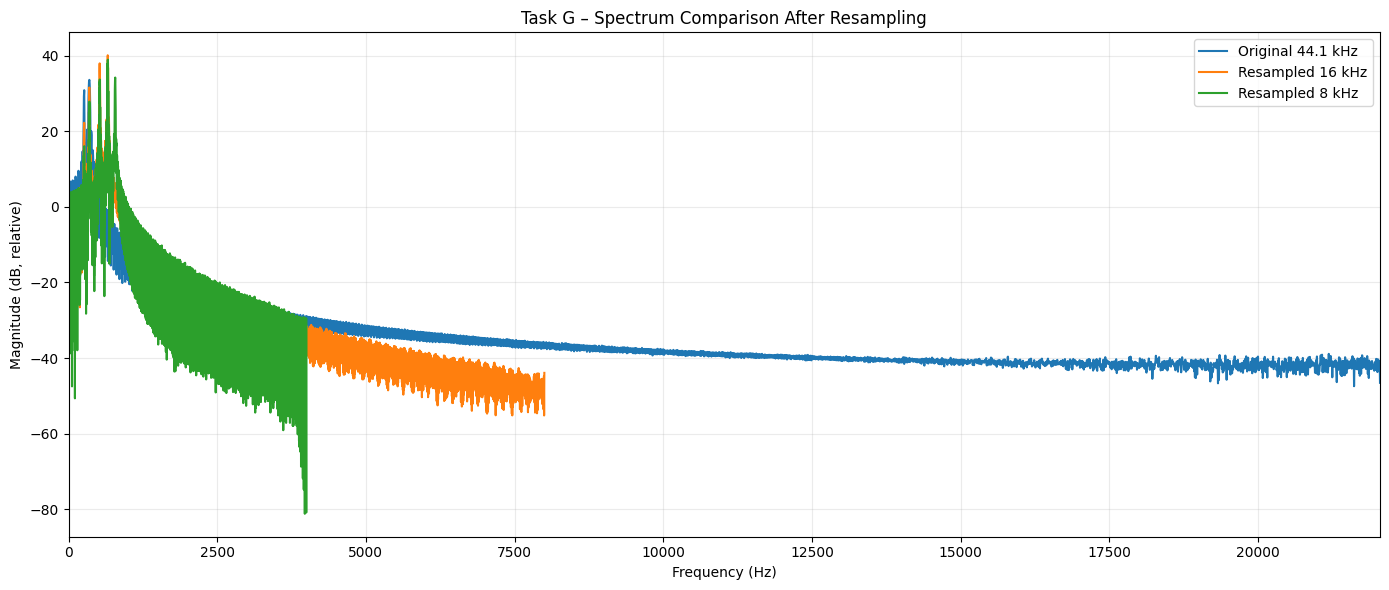

In [18]:
# G2. Resampling 16 kHz và 8 kHz

from scipy.io import wavfile

def resample_audio(x, fs_in, fs_out):
    from math import gcd

    g = gcd(fs_in, fs_out)
    up = fs_out // g
    down = fs_in // g

    return signal.resample_poly(x, up, down)


x16 = resample_audio(x_main, Fs, 16000)
x8 = resample_audio(x_main, Fs, 8000)

save_wav("audio/resampled_16k.wav", x16, 16000)
save_wav("audio/resampled_8k.wav", x8, 8000)

print("Original:", Fs, "Hz,", len(x_main), "samples")
print("16 kHz:", len(x16), "samples")
print("8 kHz:", len(x8), "samples")

# So sánh phổ
def plot_resampled_spectrum(x, fs, title):
    n = min(len(x), int(fs))
    xx = x[:n]
    f, mag, db = spectrum(xx, fs, 8192, np.hamming(len(xx)))

    plt.plot(f, db, label=title)

plt.figure(figsize=(14, 6))
plot_resampled_spectrum(x_main, Fs, "Original 44.1 kHz")
plot_resampled_spectrum(x16, 16000, "Resampled 16 kHz")
plot_resampled_spectrum(x8, 8000, "Resampled 8 kHz")

plt.xlim(0, 22050)
plt.title("Task G – Spectrum Comparison After Resampling")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB, relative)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("figures/taskG_resampling_spectrum.png", dpi=150)
plt.show()


In [19]:
# G3. PCM bitrate, theoretical file size và compression ratio

duration = len(x_main) / Fs
channels_original = audio_main.channels
bit_depth_original = audio_main.sample_width * 8

pcm_bitrate = Fs * bit_depth_original * channels_original
pcm_size_bytes = duration * pcm_bitrate / 8

print(f"Duration: {duration:.3f} s")
print(f"Fs: {Fs} Hz")
print(f"Channels: {channels_original}")
print(f"Bit depth: {bit_depth_original} bit")
print(f"Theoretical PCM bitrate: {pcm_bitrate/1000:.2f} kbps")
print(f"Theoretical PCM size: {pcm_size_bytes/1024/1024:.3f} MB")

# Kích thước file MP3 mẫu trong bộ dữ liệu của bạn không nhất thiết có,
# nên phần compression ratio được tính nếu bạn có file nén.
mp3_candidates = glob.glob("audio/*.mp3")

if mp3_candidates:
    for mp3 in mp3_candidates:
        compressed_size = os.path.getsize(mp3)
        ratio = pcm_size_bytes / compressed_size
        print(f"\nCompressed file: {os.path.basename(mp3)}")
        print(f"File size: {compressed_size/1024/1024:.3f} MB")
        print(f"Compression ratio (PCM/compressed size): {ratio:.2f}:1")
else:
    print("\nKhông có MP3 trong thư mục audio.")
    print("Bạn có thể thêm một file MP3 để thực hiện phép so sánh compression ratio thực tế.")


Duration: 59.773 s
Fs: 44100 Hz
Channels: 2
Bit depth: 16 bit
Theoretical PCM bitrate: 1411.20 kbps
Theoretical PCM size: 10.055 MB

Không có MP3 trong thư mục audio.
Bạn có thể thêm một file MP3 để thực hiện phép so sánh compression ratio thực tế.


### Nhận xét Task G

- Khi tăng số bit lượng tử từ 4 lên 8 và 16 bit, SNR đo được tăng vì sai số lượng tử giảm.
- Resampling xuống 16 kHz và 8 kHz làm giảm giới hạn Nyquist tương ứng còn 8 kHz và 4 kHz.
- Resampling chuẩn bằng `resample_poly` có bộ lọc chống aliasing, phù hợp với yêu cầu của Lab.
- PCM bitrate phụ thuộc Fs, số bit/mẫu và số kênh.
- Compression ratio được tính bằng kích thước hoặc bitrate PCM chia cho kích thước hoặc bitrate của định dạng nén.


# Thí nghiệm độc lập – Harvard speech

Phần này dùng `harvard.wav` để bổ sung thí nghiệm với tiếng nói, theo hướng dẫn của Lab khuyến khích chọn một đoạn tiếng nói bên cạnh âm nhạc.

Ta kiểm tra nhanh metadata, waveform, FFT và spectrogram.


Speech sampling rate: 44100 Hz
Speech duration: 18.356190476190477 s
Speech peak: 1.0
Speech RMS: 0.05608630396273189


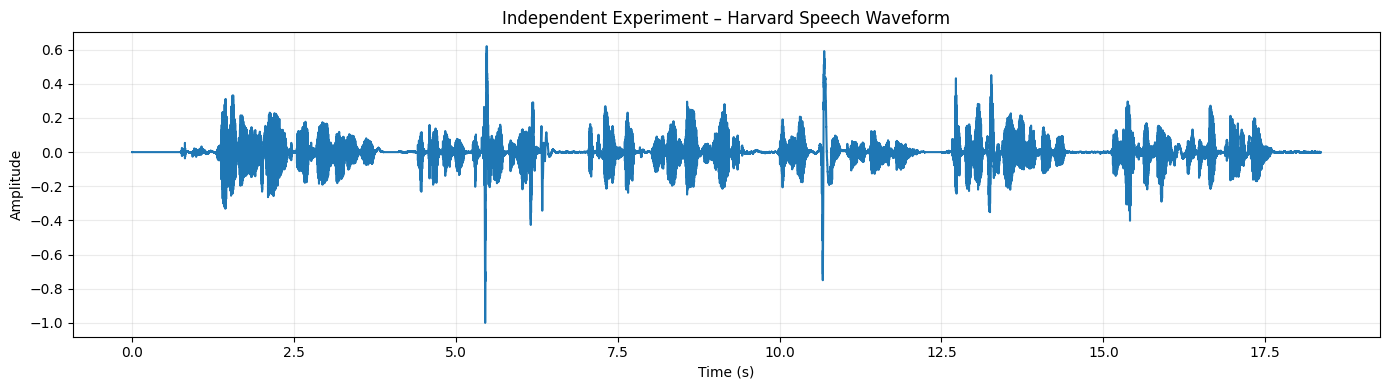

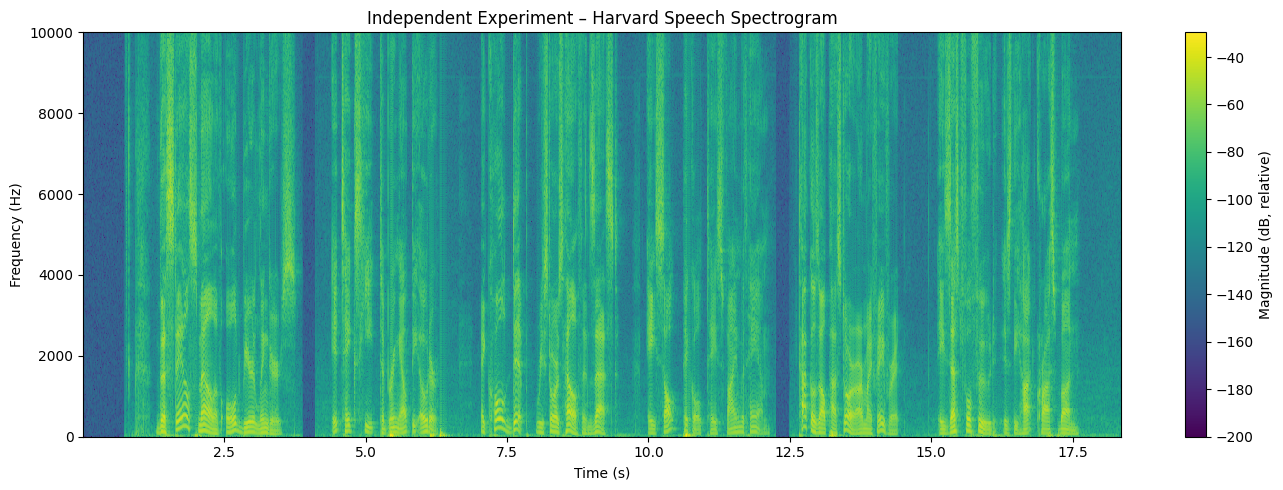

In [20]:
# Metadata và waveform của speech
print("Speech sampling rate:", Fs_speech, "Hz")
print("Speech duration:", len(x_speech) / Fs_speech, "s")
print("Speech peak:", peak(x_speech))
print("Speech RMS:", rms(x_speech))

t_speech = np.arange(len(x_speech)) / Fs_speech

plt.figure(figsize=(14, 4))
plt.plot(t_speech, x_speech)
plt.title("Independent Experiment – Harvard Speech Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("figures/speech_waveform.png", dpi=150)
plt.show()

# Spectrogram speech
L_s = round(0.025 * Fs_speech)
H_s = round(0.010 * Fs_speech)

f_s, t_s, S_s = signal.spectrogram(
    x_speech,
    fs=Fs_speech,
    window="hamming",
    nperseg=L_s,
    noverlap=L_s-H_s,
    nfft=2048,
    mode="magnitude"
)

S_s_db = 20*np.log10(np.maximum(S_s, 1e-10))

plt.figure(figsize=(14, 5))
plt.pcolormesh(t_s, f_s, S_s_db, shading="auto")
plt.ylim(0, min(10000, Fs_speech/2))
plt.colorbar(label="Magnitude (dB, relative)")
plt.title("Independent Experiment – Harvard Speech Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.tight_layout()
plt.savefig("figures/speech_spectrogram.png", dpi=150)
plt.show()


# Tổng kết kết quả Lab

## Các bằng chứng đã tạo

### Task A–B
- Metadata
- Waveform toàn tệp
- Waveform đoạn 1 giây
- Peak
- RMS
- Energy
- Clipping
- So sánh hai đoạn tín hiệu

### Task C
- FFT với Hamming
- NFFT = 2048 và 8192
- Linear spectrum
- dB spectrum
- Ít nhất 3 spectral peaks
- Frequency-bin spacing Δf

### Task D–E
- Spectrogram 25 ms / 10 ms
- So sánh frame 10 / 25 / 50 ms
- Rectangular vs Hamming
- Spectral leakage và main-lobe

### Task F
- FIR LPF 2 kHz
- FIR HPF 3 kHz
- FIR BPF 300–3400 Hz
- Frequency response
- Filter coefficients
- Audio sau lọc
- Spectrum trước/sau lọc

### Task G
- Quantization 4 / 8 / 16 bit
- Measured SNR
- Resampling 16 kHz và 8 kHz
- PCM bitrate
- Theoretical PCM file size
- Compression ratio nếu có file nén

Notebook này bám theo các yêu cầu A→G của Lab 1. Mọi kết luận cuối cùng trong báo cáo nên lấy số liệu và đồ thị thực tế sau khi chạy notebook làm căn cứ.


In [ ]:
# ==========================================
# LƯU TOÀN BỘ HÌNH VÀO FOLDER FIGURES
# ==========================================

import os
import matplotlib.pyplot as plt

# Tạo folder figures
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Lưu tất cả figure hiện đang tồn tại
figures = plt.get_fignums()

for i, fig_num in enumerate(figures, 1):
    fig = plt.figure(fig_num)
    filename = os.path.join(FIGURES_DIR, f"figure_{i}.png")
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Đã lưu: {filename}")

print(f"\nĐã lưu {len(figures)} hình vào folder '{FIGURES_DIR}'.")